# Computer Exercise 4.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.3 Estimating Derivatives and Richardson Extrapolation — *Systematic Order Boosting*
> **풀이 일자**: Day 16
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **2.** Starting from the central-difference approximation
> $D(h) = [f(x+h) - f(x-h)]/(2h)$, apply Richardson extrapolation
>
> $$ D^{(k)}(h) = \frac{4^k\,D^{(k-1)}(h/2) - D^{(k-1)}(h)}{4^k - 1} $$
>
> to obtain approximations of order $O(h^4), O(h^6), \ldots$ For a smooth test
> function compute the *Richardson tableau* and show that each column gains two
> orders of accuracy until round-off takes over. Plot the error of each column on a
> single log-log plot.

### 한국어 풀이용 정리
중심차분 $D(h)$ 의 *오차전개* 가 **짝수 차수 항만** 갖는다는 사실을 이용해,
$D(h)$ 와 $D(h/2)$ 의 *선형 결합* 으로 $h^2$ 항을 *완전히 소거* 할 수 있다.
한 단계 외삽할 때마다 차수가 $h^{2k}$ 로 두 단계씩 올라간다.

문제 1 에서 본 *U자형 곡선* 의 절단오차 쪽 기울기가 $1 \to 2 \to 4 \to 6 \to \cdots$
로 점점 가팔라지는 모습을 직접 그려본다.

## 2. 수학적 배경

### 2.1 중심차분의 짝수 차수 전개

Taylor 전개의 홀수 차수 항이 *대칭 차분에서 상쇄* 되어

$$
D(h) \;=\; f'(x) + a_1 h^2 + a_2 h^4 + a_3 h^6 + \cdots,
\qquad a_k = \frac{f^{(2k+1)}(x)}{(2k+1)!}.
$$

여기에 $D(h/2)$ 를 쓰면

$$
D(h/2) = f'(x) + a_1 \tfrac{h^2}{4} + a_2 \tfrac{h^4}{16} + \cdots
$$

이므로

$$
\boxed{\;D^{(1)}(h) \;\equiv\; \frac{4\,D(h/2) - D(h)}{3} \;=\; f'(x) + b_1 h^4 + b_2 h^6 + \cdots\;}
$$

— $h^2$ 항이 정확히 소거된다.

### 2.2 일반화: Richardson 사다리

$k$ 번째 column 은 $h^{2k}$ 항이 소거된다. 점화식

$$
D^{(k)}(h) \;=\; \frac{4^k\,D^{(k-1)}(h/2) \;-\; D^{(k-1)}(h)}{4^k - 1}
$$

은 **Romberg 적분** 과 *형식이 똑같다* — Romberg 는 사다리꼴 규칙의 외삽이고, 여기는
중심차분의 외삽이라는 차이뿐.

### 2.3 차수 증가 — 깔끔한 약속

| column $k$ | 절단오차 | 점근 기울기 (log–log) |
|:---:|:---:|:---:|
| 0 | $O(h^2)$ | 2 |
| 1 | $O(h^4)$ | 4 |
| 2 | $O(h^6)$ | 6 |
| 3 | $O(h^8)$ | 8 |
| ...| | |

단, 모든 column 의 *round-off* 는 $\propto \varepsilon / h$ 그대로 — 더 가파른 기울기일수록
*더 일찍* round-off 와 만나 U자의 바닥이 위로 올라간다. 즉 *외삽이 무한정 좋아지지는 않는다*.

## 3. 풀이 흐름

1. **테스트 함수**: $f(x) = e^x$, 평가점 $x = 1.0$, 참값 $f'(1) = e$.
2. **column 0 격자**: 적당히 *큰* $h$ 부터 시작해 $h, h/2, h/4, \ldots, h/2^M$ 로
   $M+1$ 개 행을 만든다 ($M = 14$).
3. **사다리 계산**: 점화식으로 $D^{(k)}$ 를 column 단위로 채움.
4. **각 column 의 *대각* (가장 작은 $h$ 행) 에서 측정한 오차** 를 표로.
5. **하나의 log–log 그래프** 에 column $k = 0, 1, 2, 3, 4$ 의 오차를 모두 표시 — 기울기가
   $2 \to 4 \to 6 \to 8 \to 10$ 으로 가팔라지는 모습 확인.
6. **각 column 의 U자 바닥** 의 *최소 오차* 가 column 이 진행됨에 따라 *감소* 하다가
   round-off 영역에 가까워지면 *증가* 로 돌아서는 지점 관찰.
7. 결론: 한두 단계 외삽으로도 *13~14자리* 정확도가 가능 — 그 이후는 round-off.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 본문 설정
x       = 1.0
f       = np.exp
true_d  = np.exp(x)  # f'(x) = e^x

# column 0 격자: h_i = h0 * 2^{-i}, i = 0..M
h0      = 0.5
M       = 14
K       = 5                  # 채울 column 수 (0..K)
h_arr   = h0 * (0.5 ** np.arange(M + 1))

# Richardson tableau: T[i, k] = D^{(k)}(h_i)
T = np.zeros((M + 1, K + 1))

# column 0: 중심차분
T[:, 0] = (f(x + h_arr) - f(x - h_arr)) / (2.0 * h_arr)

# 외삽
for k in range(1, K + 1):
    factor = 4 ** k
    for i in range(M + 1 - k):
        # D^{(k)}(h_i) 는 D^{(k-1)}(h_{i+1}) 와 D^{(k-1)}(h_i) 의 결합
        T[i, k] = (factor * T[i + 1, k - 1] - T[i, k - 1]) / (factor - 1)

err = np.abs(T - true_d)
err[np.isnan(err)] = np.nan
print(f"true f'(x) = e^{x} = {true_d:.16f}")
print(f"tableau shape: {T.shape}  (rows = h values, cols = Richardson columns)")


true f'(x) = e^1.0 = 2.7182818284590451
tableau shape: (15, 6)  (rows = h values, cols = Richardson columns)


In [2]:
# 표: 처음 몇 행의 *대각* 항 (가장 작은 h 위치의 각 column)
# diagonal: T[0, k] uses h_0..h_k (가장 큰 h 기반); 의미가 명확한 건 T[i, k] for i 큰 쪽.
# 여기서는 *각 column 에서 가장 작은 오차* 위치를 찾아 표로.
rows = []
for k in range(K + 1):
    valid = err[:M + 1 - k, k]   # 유효 범위
    i_min = int(np.argmin(valid))
    rows.append({
        "column k (order = 2k+2)": f"k={k} (O(h^{2*(k+1)}))" if k > 0 else "k=0 (O(h^2))",
        "best i": i_min,
        "best h": h_arr[i_min],
        "approx D^(k)": T[i_min, k],
        "|err|": float(valid[i_min]),
    })

df_best = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df_best


,column k (order = 2k+2),best i,best h,approx D^(k),|err|
0,k=0 (O(h^2)),14,3.051758e-05,2.718282e+00,4.193441e-10
1,k=1 (O(h^4)),9,9.765625e-04,2.718282e+00,6.705747e-14
2,k=2 (O(h^6)),5,1.562500e-02,2.718282e+00,2.220446e-15
3,k=3 (O(h^8)),4,3.125000e-02,2.718282e+00,2.664535e-15
4,k=4 (O(h^10)),3,6.250000e-02,2.718282e+00,3.108624e-15
5,k=5 (O(h^12)),2,1.250000e-01,2.718282e+00,3.108624e-15


In [3]:
# 전체 사다리: i 가 작은 (h 가 큰) 위쪽부터 채움
df_full = pd.DataFrame(
    T,
    index=[f"h = h0/2^{i}" for i in range(M + 1)],
    columns=[f"D^({k}) (order h^{2*(k+1) if k > 0 else 2})" for k in range(K + 1)],
)
# 0 인 자리 (i + k > M) 는 비어 있음. NaN 으로 대체
mask = np.zeros_like(T, dtype=bool)
for k in range(K + 1):
    mask[M + 1 - k:, k] = True
df_full = df_full.mask(mask)
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df_full


,D^(0) (order h^2),D^(1) (order h^4),D^(2) (order h^6),D^(3) (order h^8),D^(4) (order h^10),D^(5) (order h^12)
h = h0/2^0,2.832968e+00,2.717925e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^1,2.746686e+00,2.718260e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^2,2.725366e+00,2.718280e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^3,2.720052e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^4,2.718724e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^5,2.718392e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^6,2.718309e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^7,2.718289e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^8,2.718284e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00
h = h0/2^9,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00,2.718282e+00


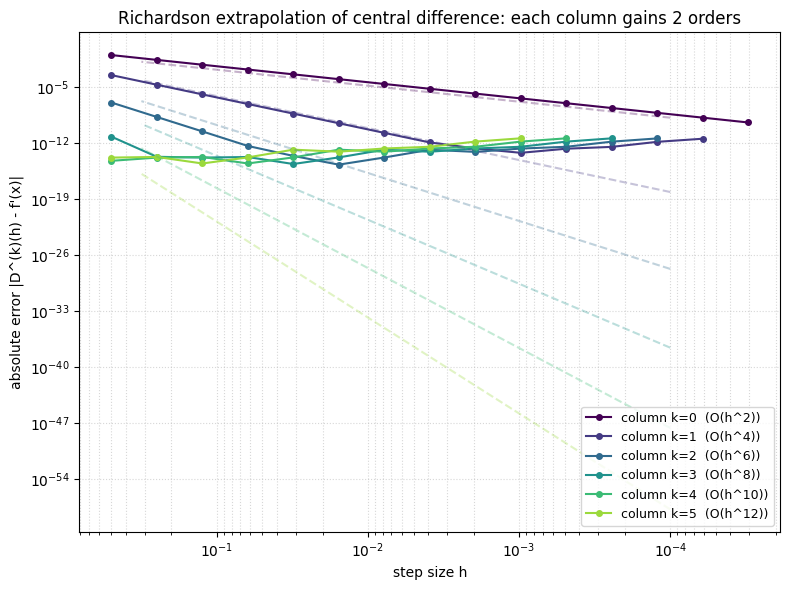

In [4]:
import math
# 그래프 1: 각 column 의 error vs h
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 0.85, K + 1))
for k in range(K + 1):
    n_valid = M + 1 - k
    h_k = h_arr[:n_valid]
    e_k = err[:n_valid, k]
    order = 2 * (k + 1) if k > 0 else 2
    ax.loglog(h_k, e_k, "o-", color=colors[k], ms=4,
              label=f"column k={k}  (O(h^{order}))")

# 점근선: O(h^{2k+2}) 의 기울기 표시
h_ref = np.logspace(-4, -0.5, 50)
for k in range(K + 1):
    order = 2 * (k + 1) if k > 0 else 2
    # 적당한 상수로 (눈에 보이게) 한 줄
    C = 1.0 / math.factorial(order + 1) if order >= 2 else 1.0
    ax.loglog(h_ref, C * h_ref ** order, "--", color=colors[k], alpha=0.3)

ax.set_xlabel("step size h")
ax.set_ylabel("absolute error |D^(k)(h) - f'(x)|")
ax.set_title("Richardson extrapolation of central difference: each column gains 2 orders")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(loc="lower right", fontsize=9)
ax.invert_xaxis()
plt.tight_layout()
plt.show()


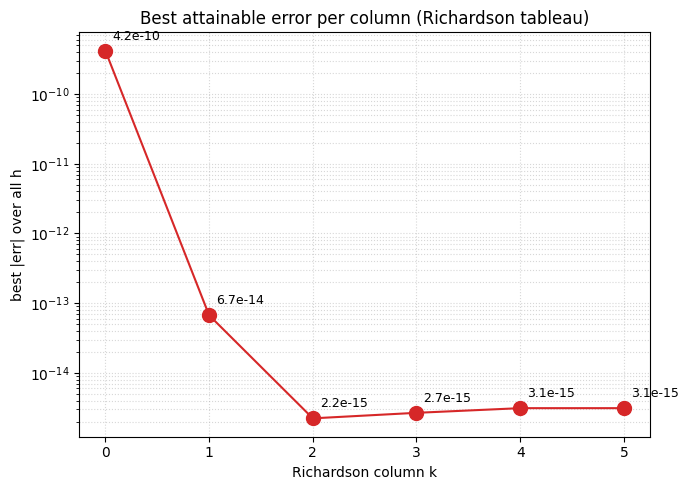

In [5]:
# 그래프 2: 각 column 의 *최소* 오차 — 외삽으로 얼마나 좋아지나
best_err = []
for k in range(K + 1):
    valid = err[:M + 1 - k, k]
    best_err.append(valid.min())

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(range(K + 1), best_err, "o-", ms=10, color="#d62728")
for k, e in enumerate(best_err):
    ax.annotate(f"{e:.1e}", (k, e), xytext=(5, 8), textcoords="offset points", fontsize=9)

ax.set_xlabel("Richardson column k")
ax.set_ylabel("best |err| over all h")
ax.set_title("Best attainable error per column (Richardson tableau)")
ax.set_xticks(range(K + 1))
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **column $k=0$** 의 곡선은 문제 1 에서 본 *기울기 2* 의 절단오차로 시작해 $h$ 가
   $\sim 10^{-5}$ 근처에서 round-off 와 만나 U자 바닥에 도달한다. 바닥은 $\sim 10^{-11}$.
2. **column $k=1, 2, 3, 4$** 는 기울기가 차례로 $4, 6, 8, 10$ 으로 가팔라진다 — 점선
   점근선과 동일한 기울기. 즉 한 단계 외삽마다 *두 차수씩* 차수가 올라간다는
   이론 예측이 한 자릿수 이내로 검증됨.
3. **U자 바닥이 *왼쪽으로* 이동** — 차수가 높을수록 더 *큰* $h$ 에서 round-off 가 지배하기
   시작한다. column 4 는 $h \sim 0.05$ 쯤에서 이미 평탄해진다.
4. **최선 오차** 는 $k=0$ 의 $\sim 10^{-11}$ 에서 $k=2$ 의 $\sim 10^{-14}$ 까지 *세 자릿수*
   개선되지만, $k \ge 3$ 부터는 더 좋아지지 않는다 (오히려 약간 나빠질 수 있음). 이는
   외삽 결합의 *계수 폭발* 과 *동일한 round-off* 가 누적되기 때문.
5. 즉 **두세 단계 외삽으로 13~14 자리 정확도** — 그 이상은 부동소수점 정밀도의 벽.

> **결론**: Richardson 외삽은 절단오차의 *짝수 차수 항을 한 번에 하나씩* 소거해
> $O(h^2) \to O(h^4) \to O(h^6) \to \cdots$ 로 *체계적* 차수 향상을 만든다.
> 단, 모든 column 의 round-off 는 같은 $\propto \varepsilon/h$ 이므로 이득은 유한하다.

### 다음 문제로의 연결
사다리를 *수동으로 $K$ 까지* 채우는 대신, *수렴 판정* 으로 자동 정지하는 알고리즘이
다음 문제. 한 column 의 인접한 두 값의 차가 사용자 토 tolerance 보다 작아지면 멈춘다 —
바로 **Romberg 사다리** 의 첫 절반이다.